In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar los datos limpios
train_df = pd.read_csv('../03_datasets/train_data_prepared.csv')
val_df = pd.read_csv('../03_datasets/val_data_prepared.csv')
test_df = pd.read_csv('../03_datasets/test_data_prepared.csv')

# ¡Eliminamos AMBOS precios de las características (X) para evitar trampas!
columnas_a_borrar = ['buy_price_log', 'rent_price']

X_train = train_df.drop(columnas_a_borrar, axis=1)
y_train = train_df['rent_price']  # <--- ¡AQUÍ ESTÁ EL GRAN CAMBIO!

X_val = val_df.drop(columnas_a_borrar, axis=1)
y_val = val_df['rent_price']      # <--- Cambio aquí también

X_test = test_df.drop(columnas_a_borrar, axis=1)
y_test = test_df['rent_price']    # <--- Y aquí

print(f"Forma de X_train: {X_train.shape}")


Forma de X_train: (11454, 16)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# 1. Arquitectura
model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(1)                                   # Salida lineal para regresión
])

# 2. Compilar con learning rate explícito
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae']
)

# 3. Callbacks mejorados
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

# 4. Entrenar con más épocas
print("Iniciando el entrenamiento de la Red Neuronal...\n")

fit_params = {
    "validation_data": (X_val, y_val),
    "epochs": 500,
    "batch_size": 32,
    "callbacks": [early_stop, reduce_lr],
    "verbose": 1
}

history = model.fit(
    X_train, y_train,**fit_params
)


I0000 00:00:1775246702.374460  225537 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775246702.374787  225537 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775246702.403167  225537 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775246703.171713  225537 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Iniciando el entrenamiento de la Red Neuronal...

Epoch 1/500


E0000 00:00:1775246703.667906  225537 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775246703.668120  225606 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775246703.683755  225537 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1229.5787 - mae: 1229.5787 - val_loss: 802.7402 - val_mae: 802.7402 - learning_rate: 0.0010
Epoch 2/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 524.4626 - mae: 524.4626 - val_loss: 570.5819 - val_mae: 570.5819 - learning_rate: 0.0010
Epoch 3/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - loss: 360.6807 - mae: 360.6807 - val_loss: 270.7853 - val_mae: 270.7853 - learning_rate: 0.0010
Epoch 4/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 361.9415 - mae: 361.9415 - val_loss: 252.6526 - val_mae: 252.6526 - learning_rate: 0.0010
Epoch 5/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - loss: 354.3593 - mae: 354.3593 - val_loss: 241.9860 - val_mae: 241.9860 - learning_rate: 0.0010
Epoch 6/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 349.1704 - mae: 349.1704 - val_loss: 250.8527 - val_mae: 250.8527 - learning_rate: 0.0010
Epoch 7/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 341.1277 - mae: 341.1277 - val_loss: 22

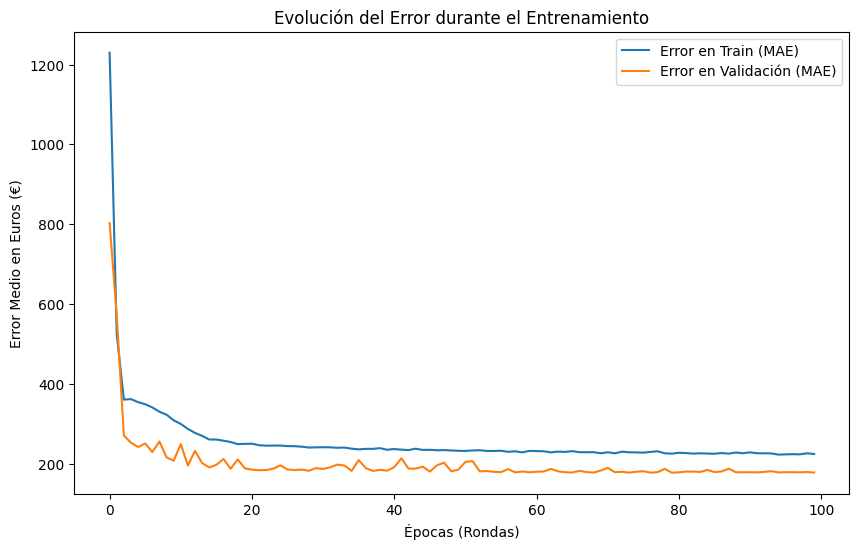

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step

--- RESULTADOS FINALES DE ALQUILER EN TEST ---
Error Absoluto Medio (MAE): 190.44 €/mes
R-Cuadrado (R2): -0.2134


In [3]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Ver cómo ha aprendido la red con un gráfico
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Error en Train (MAE)')
plt.plot(history.history['val_loss'], label='Error en Validación (MAE)')
plt.title('Evolución del Error durante el Entrenamiento')
plt.xlabel('Épocas (Rondas)')
plt.ylabel('Error Medio en Euros (€)')
plt.legend()
plt.show()

# 1. Hacer predicciones sobre los datos de TEST
predicciones_test = model.predict(X_test)

# 2. Calcular métricas finales (Directamente, sin conversiones)
mae = mean_absolute_error(y_test, predicciones_test)
r2 = r2_score(y_test, predicciones_test)

print("\n--- RESULTADOS FINALES DE ALQUILER EN TEST ---")
print(f"Error Absoluto Medio (MAE): {mae:,.2f} €/mes")
print(f"R-Cuadrado (R2): {r2:.4f}")

In [4]:
# 1. Guardar el modelo de la Red Neuronal (El "Cerebro")
model.save('../models/modelo_alquiler_dl.keras')
print("✅ Modelo de Red Neuronal guardado como 'modelo_alquiler_dl.keras'")

print("\n¡Todo empaquetado y listo!")

✅ Modelo de Red Neuronal guardado como 'modelo_alquiler_dl.keras'

¡Todo empaquetado y listo!


In [5]:
import mlflow
import mlflow.keras
from pathlib import Path

# MLflow crea el archivo mlflow.db solo si no existe
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# 1. Ajuste de ruta de mlruns la ubicación de la raíz del directorio y configuramos experimento
BASE_DIR = Path().resolve().parent  # sube un nivel desde 04_dl_notebooks/ a la raíz
mlflow.set_tracking_uri(f"file://{BASE_DIR}/mlruns")
mlflow.set_experiment(experiment_name="Madrid_Real_Estate_Predictor")

# 2. PERO le ponemos un nombre distinto a esta prueba (para saber que es alquiler)
with mlflow.start_run(run_name="rent_DL"):

    # A. Registramos los parámetros
    mlflow.log_param("epochs", fit_params["epochs"])
    mlflow.log_param("batch_size", fit_params["batch_size"])

    # B. Registramos métricas
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("MAE", mae)

    # C. Guardamos el modelo con la nueva API de MLflow 3.x
    mlflow.keras.log_model(
        model,
        name="rent_model_DL",                        # ← artifact_path → name
        registered_model_name="rent_model"        # ← lo registra directamente en el Registry
    )

print("✅ ¡Modelo de ALQUILER registrado en MLflow con éxito!")

/home/alfredo/Documentos/proyectos/proyecto_final_kc/proyecto_final/.venv/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/03 22:05:46 INFO mlflow.tracking.fluent: Experiment with name 'Madrid_Real_Estate_Predictor' does not exist. Creating a new experiment.
2026/04/03 22:05:46 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/04/03 22:05:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ ¡Modelo de ALQUILER registrado en MLflow con éxito!


/home/alfredo/Documentos/proyectos/proyecto_final_kc/proyecto_final/.venv/lib/python3.11/site-packages/mlflow/tracking/_model_registry/utils.py:220: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri)
Successfully registered model 'rent_model'.
Created version '1' of model 'rent_model'.
